In [46]:
import numpy as np
import pandas as pd

In [47]:
df = pd.read_csv('/content/Admission_Predict_Ver1.1.csv')

In [48]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
391,392,318,106,3,2.0,3.0,8.65,0,0.71
319,320,327,113,4,3.5,3.0,8.69,1,0.80
193,194,336,118,5,4.5,5.0,9.53,1,0.94
475,476,300,101,3,3.5,2.5,7.88,0,0.59
23,24,334,119,5,5.0,4.5,9.70,1,0.95


In [49]:
df.shape

(500, 9)

In [50]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [53]:
df.drop(columns=['Serial No.'],inplace=True)

In [54]:
X = df.iloc[:,0:-1]
y = df.iloc[:,-1]

In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [57]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [58]:
model = Sequential()

model.add(Dense(7,activation='relu',input_dim=7))
model.add(Dense(1,activation='linear'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [59]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

In [60]:
model.compile(loss='mean_squared_error',optimizer='Adam',metrics=['mean_absolute_error'])

In [61]:
history = model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.2674 - mean_absolute_error: 0.4747 - val_loss: 0.1786 - val_mean_absolute_error: 0.3779
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2074 - mean_absolute_error: 0.4050 - val_loss: 0.1304 - val_mean_absolute_error: 0.3094
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1595 - mean_absolute_error: 0.3369 - val_loss: 0.0976 - val_mean_absolute_error: 0.2480
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1254 - mean_absolute_error: 0.2848 - val_loss: 0.0806 - val_mean_absolute_error: 0.2151
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1049 - mean_absolute_error: 0.2570 - val_loss: 0.0731 - val_mean_absolute_error: 0.2077
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0912 - mean_absolute_error: 0.2436 - val_loss: 0.0675 - val_mean_absolute_error: 0.2024
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0809 - mean_absolute_error: 0.2323 - val_lo

In [62]:
y_pred = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [63]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7217201790516278

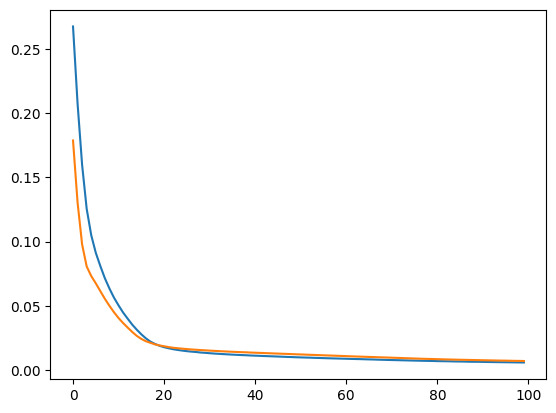

In [64]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])